<a href="https://colab.research.google.com/github/Murcha1990/GenModels_AI26/blob/main/Seminars_Base/Sem1_GPT/sem1_text_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT

**GPT** (Generative Pre-trained Transformer) — декодер.

Каждый токен видит только прошлое — будущее закрыто маской:

```
«кот  сидит  на  подоконнике»
  ↓     ↓    ↓       ↓
 видит  ←    ←       ←        ← каждый видит только себя и прошлое
```

Это делает GPT **авторегрессионной** моделью: генерирует токены один за другим.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---
## 1. Предобучение: Next Token Prediction

На каждом шаге — предсказать следующий токен по всем предыдущим:

```
«кот» → предсказать «сидит»
«кот сидит» → предсказать «на»
«кот сидит на» → предсказать «подоконнике»
```

Одна последовательность длины T даёт сразу T обучающих примеров.  
Маска нужна, чтобы при обучении токен $t$ не «подглядывал» на $t+1, t+2, ...$

---
## 2. Реализация

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):                              # x: (B, T, D)
        B, T, D = x.shape
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        scores = Q @ K.transpose(-2, -1) / D ** 0.5

        # Закрываем будущее: верхний треугольник → -∞ → 0 после softmax
        mask   = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        return self.Wo(weights @ V), weights


class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.attn  = CausalSelfAttention(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a, w = self.attn(x)
        x    = self.norm1(x + a)
        x    = self.norm2(x + self.ff(x))
        return x, w


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=32, d_ff=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos   = nn.Embedding(seq_len, d_model)
        self.block = TransformerBlock(d_model, d_ff)
        self.head  = nn.Linear(d_model, vocab_size)   # логиты → следующий токен

    def forward(self, x):               # x: (B, T)
        B, T = x.shape
        h    = self.embed(x) + self.pos(torch.arange(T, device=x.device).expand(B, -1))
        h, w = self.block(h)
        return self.head(h), w          # (B, T, vocab_size)

---
## 3. Обучение: выучить паттерн

Точность: 100%


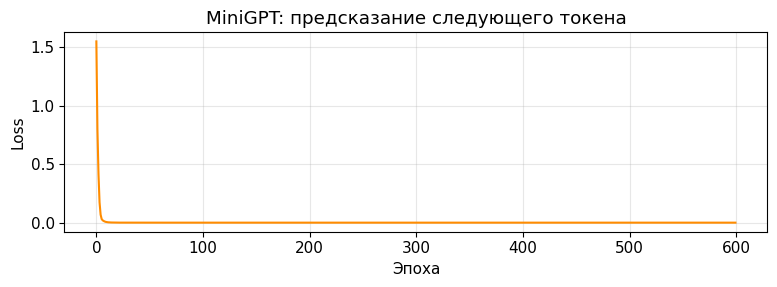

In [ ]:
# Паттерн 1 → 2 → 3 → 1 → 2 → 3 → ...
# GPT должен научиться предсказывать следующее число
VOCAB    = 4           # токены: 0 (pad), 1, 2, 3
SEQ_LEN  = 6
pattern  = [1, 2, 3] * 10

Xs = torch.tensor([pattern[i : i + SEQ_LEN]     for i in range(len(pattern) - SEQ_LEN)])
Ys = torch.tensor([pattern[i + 1 : i + SEQ_LEN + 1] for i in range(len(pattern) - SEQ_LEN)])

model   = MiniGPT(vocab_size=VOCAB, seq_len=SEQ_LEN)
opt     = optim.Adam(model.parameters(), lr=0.02)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for _ in range(600):
    logit, _ = model(Xs)
    loss = loss_fn(logit.reshape(-1, VOCAB), Ys.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    logit, attn = model(Xs)
acc = (logit.argmax(-1) == Ys).float().mean()
print(f'Точность: {acc:.0%}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='darkorange', linewidth=1.5)
ax.set_xlabel('Эпоха'); ax.set_ylabel('Loss')
ax.set_title('MiniGPT: предсказание следующего токена')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 4. Генерация

GPT генерирует токен за токеном: предсказываем следующий, добавляем в контекст, повторяем.

In [ ]:
@torch.no_grad()
def generate(model, prompt, n_new):
    tokens = list(prompt)
    for _ in range(n_new):
        x      = torch.tensor([tokens[-SEQ_LEN:]])   # последние SEQ_LEN токенов
        logit, _ = model(x)
        next_tok = logit[0, -1].argmax().item()       # жадный выбор
        tokens.append(next_tok)
    return tokens


result = generate(model, prompt=[1, 2], n_new=10)
print('Промпт [1, 2] → сгенерировано:', result)

Промпт [1, 2] → сгенерировано: [1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3]


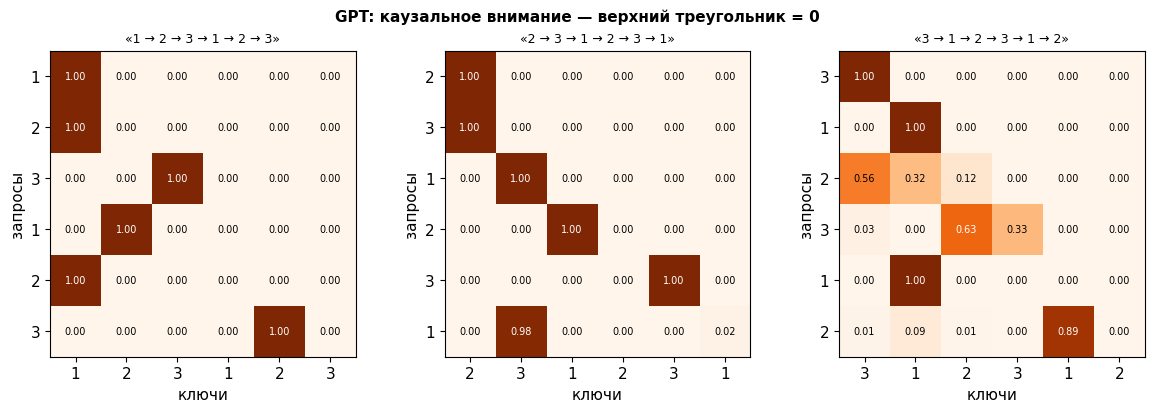

In [ ]:
# Треугольные матрицы внимания — GPT не видит будущее
show = [0, 1, 2]
seq_labels = [[str(t) for t in Xs[i].tolist()] for i in show]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx, labels in zip(axes, show, seq_labels):
    w = attn[idx].detach().numpy()
    ax.imshow(w, cmap='Oranges', vmin=0, vmax=1)
    ax.set_xticks(range(SEQ_LEN)); ax.set_xticklabels(labels)
    ax.set_yticks(range(SEQ_LEN)); ax.set_yticklabels(labels)
    ax.set_xlabel('ключи'); ax.set_ylabel('запросы')
    ax.set_title(f'«{" → ".join(labels)}»', fontsize=9)
    for i in range(SEQ_LEN):
        for j in range(SEQ_LEN):
            v = w[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.6 else 'black')

plt.suptitle('GPT: каузальное внимание — верхний треугольник = 0',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Итог

| | |
|---|---|
| Архитектура | Декодер (Causal Self-Attention) |
| Предобучение | Next Token Prediction |
| Применение | Генерация текста |
| Примеры | GPT-4, Claude, LLaMA, Mistral, DeepSeek|

GPT хорошо **генерирует** текст, потому что обучен предсказывать следующий токен.